In [1]:
# 1. Ultralytics untuk YOLOv8
!pip install -U ultralytics

# 2. Gdown untuk download dari Google Drive link besar
!pip install -U gdown

# 3. PyYAML untuk memanipulasi file data.yaml
!pip install -U PyYAML

# 4. Library standar data science (biasanya sudah ada, tapi untuk jaga-jaga)
!pip install -U pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profil

In [2]:
import os
import shutil
import random
import yaml
import gdown
from pathlib import Path
from collections import defaultdict

# 1. Download dari Google Drive
file_id = '1hs7fvHb8-TZHFj_DHCuEZZDguulgqx7Z'
url = f'https://drive.google.com/uc?id={file_id}'
output_zip = 'WIDERFace.zip'

if not os.path.exists(output_zip):
    gdown.download(url, output_zip, quiet=False)

# 2. Extract Data
if not os.path.exists('WIDER-FACE-1'):
    !unzip -q {output_zip} -d WIDER-FACE-1

def fix_wider_split_kaggle(base_path, output_path, split_ratio=(0.8, 0.1, 0.1)):
    # Setup folder tujuan
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_path, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_path, split, 'labels'), exist_ok=True)

    # Kelompokkan pasangan image-label per kategori (berdasarkan prefiks nama file WIDERFace)
    # Format biasanya: 0_Parade_marchingband_1_234.jpg -> Kategori: 0_Parade
    category_map = defaultdict(list)
    
    # Ambil dari folder 'train', 'valid', dan 'test' bawaan roboflow untuk digabung dulu
    source_folders = ['train', 'valid', 'test']
    
    for folder in source_folders:
        img_dir = Path(base_path) / folder / 'images'
        if not img_dir.exists(): continue
        
        for img_path in img_dir.glob('*.jpg'):
            label_path = Path(base_path) / folder / 'labels' / (img_path.stem + '.txt')
            if label_path.exists():
                # Ekstrak kategori (misal: "0--Parade")
                category = "_".join(img_path.stem.split('_')[:2])
                category_map[category].append((img_path, label_path))

    random.seed(42)
    final_splits = {'train': [], 'val': [], 'test': []}

    # Distribusi proporsional per kategori
    for cat, pairs in category_map.items():
        random.shuffle(pairs)
        n = len(pairs)
        tr_end = int(n * split_ratio[0])
        val_end = tr_end + int(n * split_ratio[1])
        
        final_splits['train'].extend(pairs[0:tr_end])
        final_splits['val'].extend(pairs[tr_end:val_end])
        final_splits['test'].extend(pairs[val_end:])

    # Copy file ke struktur baru
    for name, pairs in final_splits.items():
        print(f"Processing {name} split: {len(pairs)} files...")
        for img, lbl in pairs:
            shutil.copy2(img, os.path.join(output_path, name, 'images', img.name))
            shutil.copy2(lbl, os.path.join(output_path, name, 'labels', lbl.name))

    # Buat data.yaml baru
    data_yaml = {
        'train': os.path.abspath(os.path.join(output_path, 'train', 'images')),
        'val': os.path.abspath(os.path.join(output_path, 'val', 'images')),
        'test': os.path.abspath(os.path.join(output_path, 'test', 'images')),
        'nc': 1,
        'names': ['face']
    }
    
    with open(os.path.join(output_path, 'data.yaml'), 'w') as f:
        yaml.dump(data_yaml, f)

# Eksekusi
fix_wider_split_kaggle('WIDER-FACE-1', 'WIDER_FIXED')
print("Preprocessing Selesai! Dataset siap di 'WIDER_FIXED'")

Downloading...
From (original): https://drive.google.com/uc?id=1hs7fvHb8-TZHFj_DHCuEZZDguulgqx7Z
From (redirected): https://drive.google.com/uc?id=1hs7fvHb8-TZHFj_DHCuEZZDguulgqx7Z&confirm=t&uuid=e3bfbb1c-a317-453d-b41f-bfd18bbb9219
To: /kaggle/working/WIDERFace.zip
100%|██████████| 1.85G/1.85G [00:19<00:00, 92.9MB/s]


Processing train split: 12862 files...
Processing val split: 1583 files...
Processing test split: 1658 files...
Preprocessing Selesai! Dataset siap di 'WIDER_FIXED'


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=WIDER_FIXED/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=640, int8=False, 

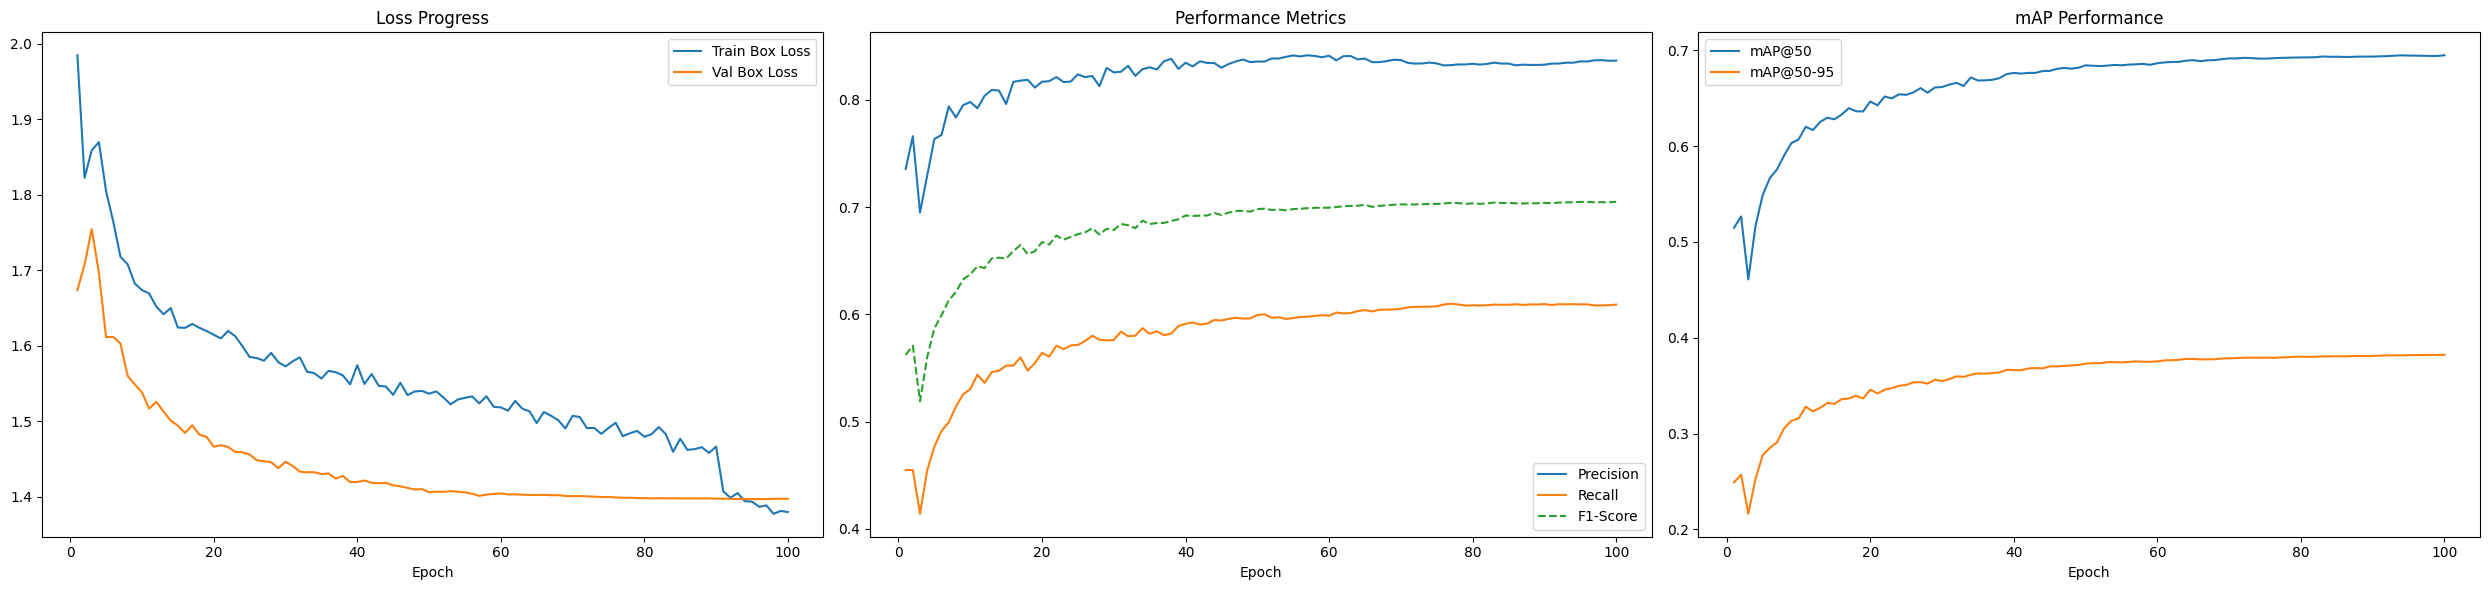

Grafik metrik berhasil disimpan sebagai 'training_metrics_horizontal.png'


In [3]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Model
model = YOLO('yolov8n.pt')

# 2. Train
results = model.train(
    data='WIDER_FIXED/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov8_wider_train',
    project='WIDER_PROJECT',
    pretrained=True,
    workers=4,
    amp=True,
    cache=False, 
    lr0 = 0.02,
    momentum=0.98,
    weight_decay=0.0001,
    hsv_v=0.6,
    mosaic=1.0,
    scale=0.5,
    translate=0.1
)

# 3. Custom Visualization & Plotting
# Ambil path folder hasil training secara dinamis dari objek 'results'
results_dir = results.save_dir
results_path = os.path.join(results_dir, 'results.csv')

print(f"Membaca hasil dari: {results_path}")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()

    # Setup Plot Horizontal (A4 style landscape)
    fig, axs = plt.subplots(1, 3, figsize=(25, 6))

    # Plot 1: Loss Progress (Box Loss)
    axs[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    axs[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    axs[0].set_title('Loss Progress')
    axs[0].set_xlabel('Epoch')
    axs[0].legend()

    # Plot 2: Performance Metrics (Precision, Recall, F1)
    axs[1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
    axs[1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
    # Hitung F1-Score secara manual dari P dan R
    f1 = 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) / (df['metrics/precision(B)'] + df['metrics/recall(B)'] + 1e-8)
    axs[1].plot(df['epoch'], f1, label='F1-Score', linestyle='--')
    axs[1].set_title('Performance Metrics')
    axs[1].set_xlabel('Epoch')
    axs[1].legend()

    # Plot 3: mAP50 & mAP50-95 (Combined)
    axs[2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50')
    axs[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95')
    axs[2].set_title('mAP Performance')
    axs[2].set_xlabel('Epoch')
    axs[2].legend()

    plt.tight_layout()
    plt.savefig('training_metrics_horizontal.png')
    plt.show()
    print("Grafik metrik berhasil disimpan sebagai 'training_metrics_horizontal.png'")
else:
    print(f"Error: File {results_path} tidak ditemukan!")

In [4]:
# 1. Load best model dari hasil training
# Gunakan path dinamis jika variabel 'results' masih ada, jika tidak, pastikan path manualnya benar
try:
    best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
except NameError:
    # Path manual jika kernel restart (sesuaikan folder angka di belakangnya jika ada)
    best_model_path = 'WIDER_PROJECT/yolov8_wider_train/weights/best.pt'

best_model = YOLO(best_model_path)

# 2. Jalankan Val pada data TEST
stats = best_model.val(data='WIDER_FIXED/data.yaml', split='test')

# 3. Print Statistik Terperinci
print("\n" + "="*30)
print("FINAL TEST STATISTICS")
print("="*30)

# Ambil metrik dari dictionary dengan key yang benar
mp = stats.results_dict['metrics/precision(B)']
mr = stats.results_dict['metrics/recall(B)']
map50 = stats.results_dict['metrics/mAP50(B)']
map50_95 = stats.results_dict['metrics/mAP50-95(B)']

f1_test = 2 * (mp * mr) / (mp + mr + 1e-8)

print(f"mAP@50:      {map50:.4f}")
print(f"mAP@50-95:   {map50_95:.4f}")
print(f"Precision:   {mp:.4f}")
print(f"Recall:      {mr:.4f}")
print(f"F1-Score:    {f1_test:.4f}")
print(f"Inference:   {stats.speed['inference']:.2f} ms per image")
print(f"Fitness:     {stats.fitness:.4f}")
print("="*30)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2240.6±428.9 MB/s, size: 130.4 KB)
val: Scanning /kaggle/working/WIDER_FIXED/test/labels... 1658 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1658/1658 1.5Kit/s 1.1s
val: New cache created: /kaggle/working/WIDER_FIXED/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 104/104 8.4it/s 12.4s
                   all       1658      16912      0.864      0.641      0.726      0.415
Speed: 0.6ms preprocess, 3.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

FINAL TEST STATISTICS
mAP@50:      0.7257
mAP@50-95:   0.4153
Precision:   0.8636
Recall:      0.6407
F1-Score:    0.7356
Inference:   3.29 ms per image
Fitness:     0.4153
